In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, optimize
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('../results', exist_ok=True)
os.makedirs('../figures/final', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.grid':        True,
    'grid.alpha':       0.25,
})

PALETTE = {
    'primary': '#185FA5',
    'accent':  '#1D9E75',
    'warn':    '#D85A30',
    'violet':  '#7C6AFF',
    'amber':   '#F5A623',
}

model  = joblib.load('../results/cece_rf_model.pkl')
master = pd.read_csv('../data/processed/cece_final_scores.csv')
master = master.rename(columns={'causal_engraftment_prob': 'historical_engraftment_rate'})
labels = pd.read_csv('../data/processed/engraftment_labels.csv')
train_labels = labels[labels['split'] == 'train']
test_labels  = labels[labels['split'] == 'test']
causal = pd.read_csv('../data/processed/causal/causal_effects.csv')
scfa   = pd.read_csv('../data/processed/micom_scfa_scores.csv')
pod_wide = pd.read_pickle('../data/processed/podlesny_wide.pkl')
pod_meta = pd.read_csv('../data/processed/podlesny_meta_split.csv')

SCFA_COLS = [c for c in [
    'butyrate_flux', 'propionate_flux', 'acetate_flux',
    'lactate_flux',  'succinate_flux',  'formate_flux', 'therapeutic_score'
] if c in scfa.columns]

df = pd.read_pickle('../results/nb09_features.pkl')
with open('../results/nb09_all_features.json') as f:
    ALL_FEATURES = json.load(f)

train_idx = df['split'] == 'train'
test_idx  = df['split'] == 'test'

DISEASE_COLS = [c for c in df.columns if c.startswith('disease_')]

SCORE_COLS = [c for c in [
    'historical_engraftment_rate','keystone_conflict_mean',
    'niche_overlap_mean','resource_accessibility',
    'crossfeeding_synergy','causal_ace'
] if c in master.columns]

print("All data loaded.")
print(f'Score columns for composite: {SCORE_COLS}')
print(f'All ML features ({len(ALL_FEATURES)}): {ALL_FEATURES}')
print(f'Train: {train_idx.sum()}  Test: {test_idx.sum()}')

All data loaded.
Score columns for composite: ['historical_engraftment_rate', 'keystone_conflict_mean', 'niche_overlap_mean', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace']
All ML features (23): ['keystone_conflict_mean', 'niche_overlap_mean', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace', 'causal_sig', 'donor_abundance', 'butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score', 'causal_ace_missing', 'resource_accessibility_missing', 'crossfeeding_synergy_missing', 'scfa_missing', 'disease_IBD', 'disease_ICI', 'disease_MDR', 'disease_MetS', 'disease_rCDI']
Train: 8697  Test: 2254


In [2]:
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split

train_obs = (
    train_labels.groupby('species')['engrafted']
    .agg(['mean','count'])
    .rename(columns={'mean':'obs_rate','count':'n_obs'})
    .reset_index()
)
train_obs = train_obs[train_obs['n_obs'] >= 3]

CALIBRATION_COLS = [c for c in SCORE_COLS if c != 'historical_engraftment_rate']

score_matrix = master[['species'] + CALIBRATION_COLS].merge(
    train_obs[['species','obs_rate']], on='species', how='inner'
).dropna()

print(f'Species with scores + observed rate: {len(score_matrix)}')
print(f'Score columns being calibrated: {CALIBRATION_COLS}')
print(f'(historical_engraftment_rate held out of calibration)')

calib_tr, calib_val = train_test_split(
    score_matrix, test_size=0.20, random_state=42
)
print(f'Calib train: {len(calib_tr)} species | Calib val: {len(calib_val)} species')

X_calib_tr  = calib_tr[CALIBRATION_COLS].values
y_calib_tr  = calib_tr['obs_rate'].values
X_calib_val = calib_val[CALIBRATION_COLS].values
y_calib_val = calib_val['obs_rate'].values

def objective(weights):
    w = np.exp(weights)
    w = w / w.sum()
    scores = X_calib_tr @ w
    r, _ = stats.spearmanr(scores, y_calib_tr)
    return -r

n_cols = len(CALIBRATION_COLS)

MANUAL_WEIGHTS = {
    'causal_ace':              0.20,
    'keystone_conflict_mean':  0.15,
    'resource_accessibility':  0.15,
    'niche_overlap_mean':      0.10,
    'crossfeeding_synergy':    0.10,
}
w_manual = np.array([MANUAL_WEIGHTS.get(c, 1/n_cols) for c in CALIBRATION_COLS])
w_manual = w_manual / w_manual.sum()

w0 = np.log(w_manual + 1e-9)

result = minimize(
    objective, x0=w0, method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6}
)

w_opt_raw    = result.x
w_calibrated = np.exp(w_opt_raw)
w_calibrated = w_calibrated / w_calibrated.sum()

print('\n── Learned Calibrated Weights (excluding historical_engraftment_rate) ──')
for col, w in zip(CALIBRATION_COLS, w_calibrated):
    print(f'  {col:<35s}  manual={MANUAL_WEIGHTS.get(col,0):.2f}  calibrated={w:.4f}')

score_manual_val     = X_calib_val @ w_manual
score_calibrated_val = X_calib_val @ w_calibrated
r_manual_val,    _   = stats.spearmanr(score_manual_val,     y_calib_val)
r_calibrated_val,_   = stats.spearmanr(score_calibrated_val, y_calib_val)

test_obs = (
    test_labels.groupby('species')['engrafted']
    .agg(['mean','count'])
    .rename(columns={'mean':'obs_rate','count':'n_obs'})
    .reset_index()
)
test_obs = test_obs[test_obs['n_obs'] >= 3]
score_test_df = master[['species'] + CALIBRATION_COLS].merge(
    test_obs[['species','obs_rate']], on='species', how='inner'
).dropna()

X_test_sp = score_test_df[CALIBRATION_COLS].values
y_test_sp = score_test_df['obs_rate'].values

score_manual_test     = X_test_sp @ w_manual
score_calibrated_test = X_test_sp @ w_calibrated
r_manual_test,    p_manual_test     = stats.spearmanr(score_manual_test,     y_test_sp)
r_calibrated_test,p_calibrated_test = stats.spearmanr(score_calibrated_test, y_test_sp)

print(f'\n── Evaluation (Spearman r, score vs observed engraftment rate) ──')
print(f'  Calib-val  — Manual: {r_manual_val:.4f}  |  Calibrated: {r_calibrated_val:.4f}')
print(f'  Test set   — Manual: {r_manual_test:.4f} (p={p_manual_test:.4f})  |  '
      f'Calibrated: {r_calibrated_test:.4f} (p={p_calibrated_test:.4f})')

delta_r = r_calibrated_test - r_manual_test
print(f'  Delta r (Calibrated - Manual) on test: {delta_r:+.4f}')
if delta_r > 0:
    print('  -> Calibrated weighting IMPROVES score alignment.')
else:
    print('  -> Manual weighting is competitive. Calibrated weights shift emphasis.')

weights_df = pd.DataFrame({
    'score_component':   CALIBRATION_COLS,
    'manual_weight':     [MANUAL_WEIGHTS.get(c,0) for c in CALIBRATION_COLS],
    'calibrated_weight': w_calibrated.round(6),
})
weights_df.to_csv('../results/calibrated_weights.csv', index=False)
print('\ncalibrated_weights.csv saved')

master_calib = master.copy()
master_calib['cece_score_manual'] = sum(
    MANUAL_WEIGHTS.get(col,0) * master_calib[col] for col in CALIBRATION_COLS
)
master_calib['cece_score_calibrated'] = master_calib[CALIBRATION_COLS].values @ w_calibrated
master_calib.to_csv('../data/processed/cece_calibrated_scores.csv', index=False)
print('cece_calibrated_scores.csv saved')

comparison_table = pd.DataFrame([
    {
        'Weight_scheme':        'Manual (NB10)',
        'Spearman_r_calib_val': round(r_manual_val, 4),
        'Spearman_r_test':      round(r_manual_test, 4),
        'p_value_test':         round(p_manual_test, 4),
        'Note': 'Fixed weights chosen a priori (historical_engraftment_rate excluded from both)'
    },
    {
        'Weight_scheme':        'CECE-Calibrated',
        'Spearman_r_calib_val': round(r_calibrated_val, 4),
        'Spearman_r_test':      round(r_calibrated_test, 4),
        'p_value_test':         round(p_calibrated_test, 4),
        'Note': 'Weights learned via Nelder-Mead on calib split, excluding historical_engraftment_rate to avoid circularity'
    },
])
comparison_table.to_csv('../results/Table_weight_comparison.csv', index=False)
print('Table_weight_comparison.csv saved')
print(comparison_table.to_string(index=False))

Species with scores + observed rate: 201
Score columns being calibrated: ['keystone_conflict_mean', 'niche_overlap_mean', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace']
(historical_engraftment_rate held out of calibration)
Calib train: 160 species | Calib val: 41 species

── Learned Calibrated Weights (excluding historical_engraftment_rate) ──
  keystone_conflict_mean               manual=0.15  calibrated=0.1197
  niche_overlap_mean                   manual=0.10  calibrated=0.5168
  resource_accessibility               manual=0.15  calibrated=0.1459
  crossfeeding_synergy                 manual=0.10  calibrated=0.1024
  causal_ace                           manual=0.20  calibrated=0.1152

── Evaluation (Spearman r, score vs observed engraftment rate) ──
  Calib-val  — Manual: 0.2113  |  Calibrated: 0.3309
  Test set   — Manual: 0.4184 (p=0.0000)  |  Calibrated: 0.5346 (p=0.0000)
  Delta r (Calibrated - Manual) on test: +0.1162
  -> Calibrated weighting IMPROVES score al

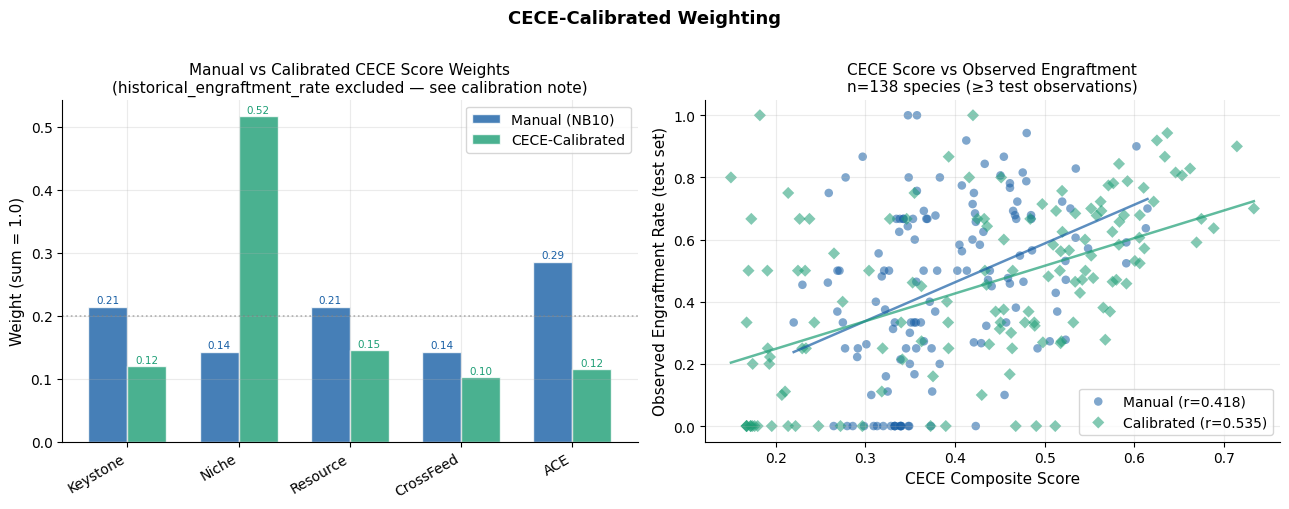

Fig_calibrated_weights.png saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x  = np.arange(len(CALIBRATION_COLS))
w  = 0.35
short_labels = [
    c.replace('keystone_conflict_mean','Keystone')
     .replace('niche_overlap_mean','Niche')
     .replace('resource_accessibility','Resource')
     .replace('crossfeeding_synergy','CrossFeed')
     .replace('causal_ace','ACE')
    for c in CALIBRATION_COLS
]

bars_m = ax.bar(x - w/2, w_manual,      w, label='Manual (NB10)',
                color=PALETTE['primary'], alpha=0.8, edgecolor='white')
bars_c = ax.bar(x + w/2, w_calibrated,  w, label='CECE-Calibrated',
                color=PALETTE['accent'],  alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Weight (sum = 1.0)', fontsize=11)
ax.set_title('Manual vs Calibrated CECE Score Weights\n'
             '(historical_engraftment_rate excluded — see calibration note)', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(1/len(CALIBRATION_COLS), color='grey', ls=':', lw=1.2, alpha=0.6,
           label='Equal weight baseline')

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=7.5, color=PALETTE['primary'])
for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=7.5, color=PALETTE['accent'])

ax = axes[1]

ax.scatter(score_manual_test, y_test_sp,
           alpha=0.55, s=38, color=PALETTE['primary'], label=f'Manual (r={r_manual_test:.3f})',
           edgecolors='none')
ax.scatter(score_calibrated_test, y_test_sp,
           alpha=0.55, s=38, color=PALETTE['accent'], label=f'Calibrated (r={r_calibrated_test:.3f})',
           marker='D', edgecolors='none')

for scores, color in [(score_manual_test, PALETTE['primary']),
                       (score_calibrated_test, PALETTE['accent'])]:
    m, b = np.polyfit(scores, y_test_sp, 1)
    xs   = np.linspace(scores.min(), scores.max(), 100)
    ax.plot(xs, m*xs+b, color=color, lw=1.8, alpha=0.7)

ax.set_xlabel('CECE Composite Score', fontsize=11)
ax.set_ylabel('Observed Engraftment Rate (test set)', fontsize=11)
ax.set_title(f'CECE Score vs Observed Engraftment\n'
             f'n={len(y_test_sp)} species (≥3 test observations)', fontsize=11)
ax.legend(fontsize=10)

plt.suptitle('CECE-Calibrated Weighting', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/final/Fig_calibrated_weights.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_calibrated_weights.png saved')

In [4]:
print('Columns in labels.csv:')
print(labels.columns.tolist())
print('\nFirst 3 rows:')
print(labels.head(3).to_string())
print('\nColumn in pod_meta:')
print(pod_meta.columns.tolist())
print(pod_meta['Sample_Type'].value_counts())

Columns in labels.csv:
['case', 'donor_id', 'post_id', 'species', 'donor_abundance', 'post_abundance', 'engrafted', 'disease', 'days_post_fmt', 'split']

First 3 rows:
             case    donor_id     post_id                          species  donor_abundance  post_abundance  engrafted disease  days_post_fmt  split
0  FRICKE_Case_16  FRICKE_16B  FRICKE_16D  Agathobaculum_butyriciproducens         0.001327        0.000000          0    rCDI          365.0  train
1  FRICKE_Case_16  FRICKE_16B  FRICKE_16D          Akkermansia_muciniphila         0.005112        0.000000          0    rCDI          365.0  train
2  FRICKE_Case_16  FRICKE_16B  FRICKE_16D              Anaerostipes_hadrus         0.223499        0.166741          1    rCDI          365.0  train

Column in pod_meta:
['Manuscript', 'Study', 'Disease_Group', 'Disease', 'Case_Name', 'Name', 'Donor.Name', 'Sample_Type', 'Days_Since_FMT', 'Case_ABx', 'ABx_days', 'ABx_PostFMT', 'Lavage', 'FMT_route', 'FMT_rounds', 'Colonoscopy_n', 'N

In [5]:
test_case = 'FRICKE_Case_16'
print(pod_meta[pod_meta['Case_Name'] == test_case][['Case_Name','Name','Sample_Type']])

        Case_Name        Name   Sample_Type
0  FRICKE_Case_16  FRICKE_16A  Pre Post-ABx
9  FRICKE_Case_16  FRICKE_16D          Post


In [6]:
print(pod_meta[pod_meta['Sample_Type'] == 'Donor'][
    ['Case_Name','Name','Donor.Name']
].head(10).to_string())

   Case_Name        Name Donor.Name
21       NaN  FRICKE_16B        NaN
22       NaN  FRICKE_18B        NaN
23       NaN  FRICKE_19B        NaN
24       NaN  FRICKE_20B        NaN
25       NaN  FRICKE_23B        NaN
26       NaN  FRICKE_28B        NaN
27       NaN  FRICKE_29B        NaN
28       NaN  FRICKE_54B        NaN
29       NaN   FRICKE_9B        NaN
75       NaN        FMT1        NaN


In [7]:
print(labels[['case','donor_id','post_id']].drop_duplicates().head(10).to_string())

               case    donor_id     post_id
0    FRICKE_Case_16  FRICKE_16B  FRICKE_16D
46   FRICKE_Case_18  FRICKE_18B  FRICKE_18C
85   FRICKE_Case_19  FRICKE_19B  FRICKE_19C
113  FRICKE_Case_20  FRICKE_20B  FRICKE_20E
163  FRICKE_Case_23  FRICKE_23B  FRICKE_23G
195  FRICKE_Case_28  FRICKE_28B  FRICKE_28C
229  FRICKE_Case_29  FRICKE_29B  FRICKE_29I
256  FRICKE_Case_54  FRICKE_54B  FRICKE_54C
290   FRICKE_Case_9   FRICKE_9B   FRICKE_9E
308      ALM_Case_4        FMT2       FMT43


In [8]:
ace_df = causal[['species','ace']].copy()
ace_df['ace_abs'] = ace_df['ace'].abs()
max_ace = ace_df['ace_abs'].max()
if max_ace > 0:
    ace_df['ace_norm'] = ace_df['ace_abs'] / max_ace
else:
    ace_df['ace_norm'] = 1.0 / len(ace_df)
ace_df = ace_df.set_index('species')

print(f'ACE estimated for {len(ace_df)} species')
print(f'ACE range: {ace_df["ace"].min():.4f} to {ace_df["ace"].max():.4f}')

donor_lookup = pod_meta[
    pod_meta['Sample_Type'] == 'Donor'
].set_index('Name')

recip_lookup = pod_meta[
    pod_meta['Sample_Type'].str.startswith('Pre')
].groupby('Case_Name').first()

print(f'Donor samples: {len(donor_lookup)}')
print(f'Recipient pre-FMT samples: {len(recip_lookup)}')

def compute_drci(donor_profile, recipient_profile, ace_df):
    species_common = ace_df.index.intersection(
        donor_profile.index).intersection(recipient_profile.index)
    if len(species_common) == 0:
        return 0.0
    d_abund = donor_profile[species_common].fillna(0).clip(0, 1)
    r_abund = recipient_profile[species_common].fillna(0).clip(0, 1)
    ace_w   = ace_df.loc[species_common, 'ace_norm']
    drci_raw = (ace_w * d_abund * (1 - r_abund)).sum()
    max_possible = ace_w.sum()
    if max_possible > 0:
        return float(drci_raw / max_possible)
    return 0.0

JOIN_COL = 'case'

drci_records = []
skipped      = 0

cases = labels[JOIN_COL].unique()
print(f'\nComputing DRCI for {len(cases)} transplant cases...')

for case_id in cases:
    case_rows = labels[labels['case'] == case_id]
    if len(case_rows) == 0:
        skipped += 1
        drci_records.append({JOIN_COL: case_id, 'drci': np.nan})
        continue

    case_donor = case_rows['donor_id'].iloc[0]

    if case_donor not in donor_lookup.index or case_donor not in pod_wide.index:
        skipped += 1
        drci_records.append({JOIN_COL: case_id, 'drci': np.nan})
        continue

    if case_id not in recip_lookup.index:
        skipped += 1
        drci_records.append({JOIN_COL: case_id, 'drci': np.nan})
        continue

    recip_name = recip_lookup.loc[case_id, 'Name']
    if recip_name not in pod_wide.index:
        skipped += 1
        drci_records.append({JOIN_COL: case_id, 'drci': np.nan})
        continue

    d_prof = pod_wide.loc[case_donor]
    r_prof = pod_wide.loc[recip_name]
    if isinstance(d_prof, pd.DataFrame): d_prof = d_prof.iloc[0]
    if isinstance(r_prof, pd.DataFrame): r_prof = r_prof.iloc[0]

    drci_val = compute_drci(d_prof, r_prof, ace_df)
    drci_records.append({JOIN_COL: case_id, 'drci': drci_val})

drci_case_df = pd.DataFrame(drci_records)
print(f'DRCI computed: {len(drci_case_df)} cases | skipped: {skipped}')

valid = drci_case_df['drci'].dropna()
print(f'DRCI range: {valid.min():.4f} – {valid.max():.4f}')
print(f'DRCI mean:  {valid.mean():.4f}')

df_with_drci = df.merge(drci_case_df, on=JOIN_COL, how='left')
df_with_drci['drci'] = df_with_drci['drci'].fillna(df_with_drci['drci'].median())

drci_case_df.to_csv('../results/drci_features.csv', index=False)
print('drci_features.csv saved')

ACE estimated for 131 species
ACE range: -0.2530 to 0.3677
Donor samples: 297
Recipient pre-FMT samples: 259

Computing DRCI for 203 transplant cases...
DRCI computed: 203 cases | skipped: 3
DRCI range: 0.0035 – 0.0141
DRCI mean:  0.0078
drci_features.csv saved


In [9]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

N_BOOTSTRAP = 1000

train_df_drci = df_with_drci[df_with_drci['split'] == 'train'].copy()
test_df_drci  = df_with_drci[df_with_drci['split'] == 'test'].copy()

X_train_base = train_df_drci[ALL_FEATURES].fillna(0)
y_train_base = train_df_drci['engrafted']
X_test_base  = test_df_drci[ALL_FEATURES].fillna(0)
y_test_base  = test_df_drci['engrafted']

ALL_FEATURES_DRCI = ALL_FEATURES + ['drci']
X_train_drci = train_df_drci[ALL_FEATURES_DRCI].fillna(0)
X_test_drci  = test_df_drci[ALL_FEATURES_DRCI].fillna(0)

RF_PARAMS = dict(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    max_features='sqrt', random_state=42, n_jobs=-1
)

model_base = RandomForestClassifier(**RF_PARAMS)
model_base.fit(X_train_base, y_train_base)
y_prob_base = model_base.predict_proba(X_test_base)[:, 1]
auc_base    = roc_auc_score(y_test_base, y_prob_base)
ap_base     = average_precision_score(y_test_base, y_prob_base)

model_drci = RandomForestClassifier(**RF_PARAMS)
model_drci.fit(X_train_drci, y_train_base)
y_prob_drci = model_drci.predict_proba(X_test_drci)[:, 1]
auc_drci    = roc_auc_score(y_test_base, y_prob_drci)
ap_drci     = average_precision_score(y_test_base, y_prob_drci)

def bootstrap_auc(y_true, y_prob, n_boot=N_BOOTSTRAP, seed=42):
    rng  = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true.iloc[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true.iloc[idx], y_prob[idx]))
    return np.percentile(aucs, [2.5, 97.5])

ci_base  = bootstrap_auc(y_test_base, y_prob_base)
ci_drci  = bootstrap_auc(y_test_base, y_prob_drci)

print('── DRCI Impact on Model Performance ──')
print(f'Without DRCI: AUROC={auc_base:.4f} (95% CI: {ci_base[0]:.3f}–{ci_base[1]:.3f})  AUPRC={ap_base:.4f}')
print(f'With DRCI:    AUROC={auc_drci:.4f} (95% CI: {ci_drci[0]:.3f}–{ci_drci[1]:.3f})  AUPRC={ap_drci:.4f}')
print(f'Delta AUROC: {auc_drci - auc_base:+.4f}')

if auc_drci > auc_base:
    print('\n→ DRCI IMPROVES predictive performance.')
elif auc_drci >= auc_base - 0.005:
    print('\n→ DRCI is neutral (within noise).')
else:
    print('\n→ DRCI slightly hurts AUROC.')

drci_importance = dict(zip(ALL_FEATURES_DRCI, model_drci.feature_importances_))
drci_rank = sorted(drci_importance.items(), key=lambda x: x[1], reverse=True)
drci_position = [i for i,(f,_) in enumerate(drci_rank) if f == 'drci']
print(f'\nDRCI feature importance rank: {drci_position[0]+1} of {len(ALL_FEATURES_DRCI)}')
print(f'DRCI importance value: {drci_importance["drci"]:.4f}')

drci_impact_table = pd.DataFrame([
    {
        'Model':        'Random Forest (baseline, no DRCI)',
        'AUROC':        round(auc_base, 4),
        'AUROC_CI_lo':  round(ci_base[0], 4),
        'AUROC_CI_hi':  round(ci_base[1], 4),
        'AUPRC':        round(ap_base, 4),
        'N_features':   len(ALL_FEATURES),
    },
    {
        'Model':        'Random Forest + DRCI',
        'AUROC':        round(auc_drci, 4),
        'AUROC_CI_lo':  round(ci_drci[0], 4),
        'AUROC_CI_hi':  round(ci_drci[1], 4),
        'AUPRC':        round(ap_drci, 4),
        'N_features':   len(ALL_FEATURES_DRCI),
    },
])
drci_impact_table.to_csv('../results/Table_DRCI_impact.csv', index=False)
print('\nTable_DRCI_impact.csv saved')
print(drci_impact_table.to_string(index=False))

── DRCI Impact on Model Performance ──
Without DRCI: AUROC=0.7773 (95% CI: 0.759–0.797)  AUPRC=0.7916
With DRCI:    AUROC=0.7715 (95% CI: 0.753–0.791)  AUPRC=0.7853
Delta AUROC: -0.0058

→ DRCI slightly hurts AUROC.

DRCI feature importance rank: 1 of 24
DRCI importance value: 0.2004

Table_DRCI_impact.csv saved
                            Model  AUROC  AUROC_CI_lo  AUROC_CI_hi  AUPRC  N_features
Random Forest (baseline, no DRCI) 0.7773       0.7587       0.7967 0.7916          23
             Random Forest + DRCI 0.7715       0.7530       0.7914 0.7853          24


In [10]:
print("── DRCI Variance Decomposition ──")
print(f"DRCI range:    {drci_case_df['drci'].min():.4f} – {drci_case_df['drci'].max():.4f}")
print(f"DRCI std:      {drci_case_df['drci'].std():.4f}")
print(f"DRCI CV:       {drci_case_df['drci'].std() / drci_case_df['drci'].mean():.3f}")

print(f"\nACE score range: {ace_df['ace_norm'].min():.4f} – {ace_df['ace_norm'].max():.4f}")
print(f"ACE score mean:  {ace_df['ace_norm'].mean():.4f}")

donor_profiles = pod_meta[pod_meta['Sample_Type'] == 'Donor']['Name'].values
donor_profiles = [d for d in donor_profiles if d in pod_wide.index]
mean_nonzero = np.mean([
    (pod_wide.loc[d] > 0).mean() 
    for d in donor_profiles[:20]
])
print(f"\nMean donor profile sparsity: {mean_nonzero:.3f} non-zero species")
print(f"(DRCI is suppressed by high sparsity × small ACE values)")

── DRCI Variance Decomposition ──
DRCI range:    0.0035 – 0.0141
DRCI std:      0.0019
DRCI CV:       0.242

ACE score range: 0.0000 – 1.0000
ACE score mean:  0.2816

Mean donor profile sparsity: 0.118 non-zero species
(DRCI is suppressed by high sparsity × small ACE values)


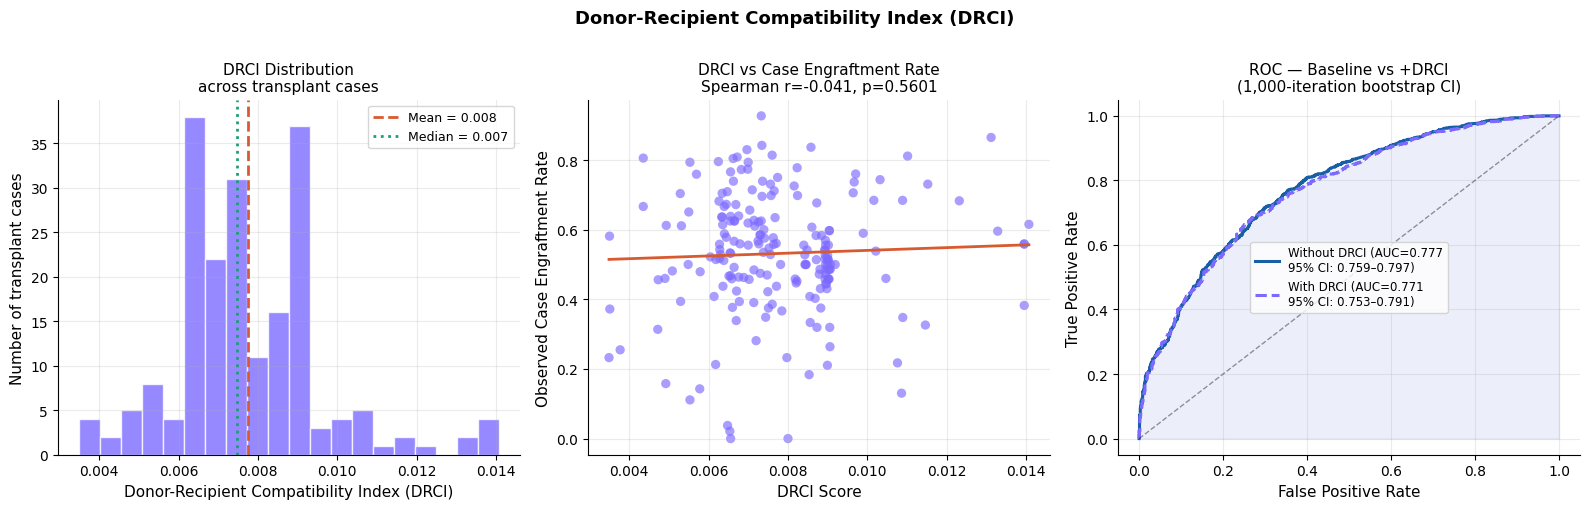

Fig_DRCI_impact.png saved


In [11]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
valid_drci = drci_case_df['drci'].dropna()
ax.hist(valid_drci, bins=20, color=PALETTE['violet'], alpha=0.8, edgecolor='white')
ax.axvline(valid_drci.mean(),   color=PALETTE['warn'],   lw=2, ls='--',
           label=f'Mean = {valid_drci.mean():.3f}')
ax.axvline(valid_drci.median(), color=PALETTE['accent'], lw=2, ls=':',
           label=f'Median = {valid_drci.median():.3f}')
ax.set_xlabel('Donor-Recipient Compatibility Index (DRCI)', fontsize=11)
ax.set_ylabel('Number of transplant cases', fontsize=11)
ax.set_title('DRCI Distribution\nacross transplant cases', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]

if JOIN_COL in labels.columns:
    case_eng = labels.groupby(JOIN_COL)['engrafted'].mean().reset_index()
    case_eng.columns = [JOIN_COL, 'engraftment_rate']
    drci_vs_eng = drci_case_df.merge(case_eng, on=JOIN_COL, how='inner').dropna()
    
    if len(drci_vs_eng) > 3:
        r_drci, p_drci = stats.spearmanr(drci_vs_eng['drci'], drci_vs_eng['engraftment_rate'])
        ax.scatter(drci_vs_eng['drci'], drci_vs_eng['engraftment_rate'],
                   alpha=0.65, s=45, color=PALETTE['violet'], edgecolors='none')
        m, b = np.polyfit(drci_vs_eng['drci'], drci_vs_eng['engraftment_rate'], 1)
        xs   = np.linspace(drci_vs_eng['drci'].min(), drci_vs_eng['drci'].max(), 100)
        ax.plot(xs, m*xs+b, color=PALETTE['warn'], lw=2)
        ax.set_title(f'DRCI vs Case Engraftment Rate\nSpearman r={r_drci:.3f}, p={p_drci:.4f}', fontsize=11)
    else:
        ax.text(0.5, 0.5, 'Insufficient case-level data\nfor scatter plot',
                ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')
else:
    ax.text(0.5, 0.5, 'JOIN_COL not set correctly\n— re-run Cell 5',
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')

ax.set_xlabel('DRCI Score', fontsize=11)
ax.set_ylabel('Observed Case Engraftment Rate', fontsize=11)

ax = axes[2]
fpr_b, tpr_b, _ = roc_curve(y_test_base, y_prob_base)
fpr_d, tpr_d, _ = roc_curve(y_test_base, y_prob_drci)

ax.plot(fpr_b, tpr_b, color=PALETTE['primary'], lw=2.2,
        label=f'Without DRCI (AUC={auc_base:.3f}\n95% CI: {ci_base[0]:.3f}–{ci_base[1]:.3f})')
ax.plot(fpr_d, tpr_d, color=PALETTE['violet'],  lw=2.2, ls='--',
        label=f'With DRCI (AUC={auc_drci:.3f}\n95% CI: {ci_drci[0]:.3f}–{ci_drci[1]:.3f})')
ax.fill_between(fpr_b, tpr_b, alpha=0.05, color=PALETTE['primary'])
ax.fill_between(fpr_d, tpr_d, alpha=0.05, color=PALETTE['violet'])
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC — Baseline vs +DRCI\n(1,000-iteration bootstrap CI)', fontsize=11)
ax.legend(fontsize=8.5)

plt.suptitle('Donor-Recipient Compatibility Index (DRCI)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/final/Fig_DRCI_impact.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_DRCI_impact.png saved')

In [12]:
import shap
print('shap:', shap.__version__)


shap: 0.49.1


In [13]:
import shap
from sklearn.ensemble import RandomForestClassifier

train_df_nb09 = df[df['split'] == 'train'].copy()
test_df_nb09  = df[df['split'] == 'test'].copy()
X_train_nb09  = train_df_nb09[ALL_FEATURES].fillna(0)
X_test_nb09   = test_df_nb09[ALL_FEATURES].fillna(0)
y_train_nb09  = train_df_nb09['engrafted']

print('Retraining Random Forest for SHAP (same params as NB09)...')
model_shap = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    max_features='sqrt', random_state=42, n_jobs=-1
)
model_shap.fit(X_train_nb09, y_train_nb09)
print('Done.')

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_test_nb09)

print(f'DEBUG shap_values type: {type(shap_values)}')
print(f'DEBUG X_test_nb09.shape: {X_test_nb09.shape}  '
      f'(duplicate columns: {X_test_nb09.columns.duplicated().any()})')

if hasattr(shap_values, 'values') and not isinstance(shap_values, (list, np.ndarray)):
    shap_values = shap_values.values

if isinstance(shap_values, list):
    print(f'DEBUG shap_values is a list of length {len(shap_values)}')
    shap_values = shap_values[-1]
elif hasattr(shap_values, 'ndim'):
    print(f'DEBUG shap_values.ndim: {shap_values.ndim}, shape: {shap_values.shape}')
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    elif shap_values.ndim == 1 and getattr(shap_values, 'dtype', None) == object:
        shap_values = np.stack(list(shap_values))[-1]

shap_values = np.asarray(shap_values)
print(f'DEBUG normalized shap_values.shape: {shap_values.shape}')

feature_names = X_test_nb09.columns.tolist()
if len(feature_names) != shap_values.shape[1]:
    print(f'WARNING: {len(feature_names)} columns vs {shap_values.shape[1]} '
          f'shap columns -- falling back to positional names. This means '
          f'X_test_nb09 has a width mismatch upstream.')
    feature_names = [f'feature_{i}' for i in range(shap_values.shape[1])]

shap_importance = pd.DataFrame({
    'feature':       feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('\nSHAP importance per feature:')
print(shap_importance.to_string(index=False))

FEATURE_GROUPS = {
    'ecological': [c for c in ['keystone_conflict_mean', 'niche_overlap_mean']
                   if c in ALL_FEATURES],
    'causal':     [c for c in ['causal_ace', 'causal_sig', 'causal_ace_missing']
                   if c in ALL_FEATURES],
    'metabolic':  [c for c in ['resource_accessibility', 'crossfeeding_synergy',
                                'resource_accessibility_missing',
                                'crossfeeding_synergy_missing']
                   if c in ALL_FEATURES],
    'scfa':       [c for c in SCFA_COLS + ['scfa_missing'] if c in ALL_FEATURES],
    'disease':    [c for c in DISEASE_COLS if c in ALL_FEATURES],
    'donor':      [c for c in ['donor_abundance'] if c in ALL_FEATURES],
}

shap_imp_dict = dict(zip(shap_importance['feature'], shap_importance['mean_abs_shap']))

group_shap = {}
for group, features in FEATURE_GROUPS.items():
    group_shap[group] = sum(shap_imp_dict.get(f, 0) for f in features)

total_shap = sum(group_shap.values())
group_shap_norm = {g: v / total_shap for g, v in group_shap.items()}

print('\n── SHAP importance by feature group ──')
for g, v in sorted(group_shap_norm.items(), key=lambda x: -x[1]):
    print(f'  {g:12s}: {v:.4f}  ({v*100:.1f}%)')

GA_SHAP_WEIGHTS = group_shap_norm.copy()

Retraining Random Forest for SHAP (same params as NB09)...
Done.
Computing SHAP values...
DEBUG shap_values type: <class 'numpy.ndarray'>
DEBUG X_test_nb09.shape: (2254, 23)  (duplicate columns: False)
DEBUG shap_values.ndim: 3, shape: (2254, 23, 2)
DEBUG normalized shap_values.shape: (2254, 23)

SHAP importance per feature:
                       feature  mean_abs_shap
            niche_overlap_mean       0.079879
               donor_abundance       0.065831
          crossfeeding_synergy       0.036291
        keystone_conflict_mean       0.026297
        resource_accessibility       0.024861
                    causal_ace       0.023440
                  acetate_flux       0.017435
             therapeutic_score       0.012932
                  disease_MetS       0.012664
                succinate_flux       0.010863
                  formate_flux       0.010046
            causal_ace_missing       0.009643
                    causal_sig       0.006069
                   disease_IB

In [14]:
import random

random.seed(42)
np.random.seed(42)

master_idx = master.set_index('species')

SCORE_COLS_GA = [c for c in [
    'historical_engraftment_rate', 'keystone_conflict_mean',
    'niche_overlap_mean', 'resource_accessibility',
    'crossfeeding_synergy',
] if c in master.columns]

SCFA_GA = [c for c in SCFA_COLS if c in master.columns]

def get_group_scores(species_subset):
    rows = master_idx.loc[
        [s for s in species_subset if s in master_idx.index]
    ]
    if len(rows) == 0:
        return {g: 0.0 for g in FEATURE_GROUPS}

    ecological = rows[['keystone_conflict_mean','niche_overlap_mean']].mean().mean() \
        if all(c in rows.columns for c in ['keystone_conflict_mean','niche_overlap_mean']) else 0.0

    causal_s = rows['causal_ace'].mean() if 'causal_ace' in rows.columns else 0.0

    metabolic_cols = [c for c in ['resource_accessibility','crossfeeding_synergy'] if c in rows.columns]
    metabolic_s    = rows[metabolic_cols].mean().mean() if metabolic_cols else 0.0

    scfa_cols = [c for c in SCFA_GA if c in rows.columns]
    scfa_s    = rows[scfa_cols].mean().mean() if scfa_cols else 0.0
    return {
        'ecological': ecological,
        'causal':     causal_s,
        'metabolic':  metabolic_s,
        'scfa':       scfa_s,
        'donor':      0.0,
    }

MIN_SPECIES = 5
MAX_SPECIES = 20
POP_SIZE    = 60
N_GEN       = 30


GA_DISEASE_TARGET = 'disease_IBD'

def fitness_original(chromosome, species_pool, donor_profile, size_penalty=0.005):
    selected = [sp for sp, bit in zip(species_pool, chromosome) if bit == 1]
    n = len(selected)
    if n < MIN_SPECIES or n > MAX_SPECIES: return 0.0
    rows = []
    for sp in selected:
        if sp not in master_idx.index: continue
        row = master_idx.loc[sp].to_dict()
        row['donor_abundance'] = float(donor_profile.get(sp, 0.0))
        for dcol in DISEASE_COLS:
            row[dcol] = 1 if dcol == GA_DISEASE_TARGET else 0
        rows.append(row)
    if not rows: return 0.0
    feat_df = pd.DataFrame(rows)
    cols    = [c for c in ALL_FEATURES if c in feat_df.columns]
    X       = feat_df[cols].fillna(0)
    if hasattr(model, 'feature_names_in_'):
        X = X[list(model.feature_names_in_)]
    proba   = float(model.predict_proba(X)[:, 1].mean())
    return proba - size_penalty * (n - MIN_SPECIES)


def fitness_equal(chromosome, species_pool, donor_profile, size_penalty=0.005):
    selected = [sp for sp, bit in zip(species_pool, chromosome) if bit == 1]
    n = len(selected)
    if n < MIN_SPECIES or n > MAX_SPECIES: return 0.0
    scores = get_group_scores(selected)
    w = 1.0 / len(scores)
    return sum(w * v for v in scores.values()) - size_penalty * (n - MIN_SPECIES)


_SHAP_W_NO_DISEASE  = {g: w for g, w in GA_SHAP_WEIGHTS.items() if g != 'disease'}
_SHAP_W_NORM_FACTOR = sum(_SHAP_W_NO_DISEASE.values()) or 1.0

def fitness_shap(chromosome, species_pool, donor_profile, size_penalty=0.005):
    selected = [sp for sp, bit in zip(species_pool, chromosome) if bit == 1]
    n = len(selected)
    if n < MIN_SPECIES or n > MAX_SPECIES: return 0.0
    scores = get_group_scores(selected)
    weighted = sum(_SHAP_W_NO_DISEASE.get(g, 0) * v for g, v in scores.items())
    return weighted / _SHAP_W_NORM_FACTOR - size_penalty * (n - MIN_SPECIES)


def run_ga_generic(donor_profile, fitness_fn, n_gen=N_GEN, crossover_r=0.80, mutation_r=0.08):
    present    = donor_profile[donor_profile > 0.001]
    ga_species = sorted(set(present.index) & set(master_idx.index))
    if len(ga_species) < MIN_SPECIES:
        return [], 0.0
    n_sp   = len(ga_species)
    pop = []
    for _ in range(POP_SIZE):
        n   = random.randint(MIN_SPECIES, min(MAX_SPECIES, n_sp))
        idx = random.sample(range(n_sp), n)
        c   = [0] * n_sp
        for i in idx: c[i] = 1
        pop.append(c)

    best_c, best_f = None, -1.0

    for _ in range(n_gen):
        fits     = [fitness_fn(c, ga_species, present) for c in pop]
        gen_best = max(fits)
        if gen_best > best_f:
            best_f = gen_best
            best_c = pop[fits.index(gen_best)][:]
        new_pop = [best_c[:]]
        while len(new_pop) < POP_SIZE:
            contestants = random.sample(range(len(pop)), 3)
            p1 = pop[max(contestants, key=lambda i: fits[i])][:]
            contestants = random.sample(range(len(pop)), 3)
            p2 = pop[max(contestants, key=lambda i: fits[i])][:]
            if random.random() < crossover_r:
                pt = random.randint(1, len(p1)-1)
                c1 = p1[:pt] + p2[pt:]
            else:
                c1 = p1[:]
            c1 = [1-b if random.random() < mutation_r else b for b in c1]
            new_pop.append(c1)
        pop = new_pop

    best_species = [sp for sp, bit in zip(ga_species, best_c) if bit == 1]
    return best_species, best_f

all_donors = pod_meta[
    pod_meta['Sample_Type'].str.strip().str.lower() == 'donor'
]['Name'].dropna().values
donors = [d for d in all_donors if d in pod_wide.index]
N_DONORS_COMPARE = min(10, len(donors))

print(f'Comparing 3 fitness functions on {N_DONORS_COMPARE} donors...')

results_compare = []
for donor_id in donors[:N_DONORS_COMPARE]:
    prof = pod_wide.loc[donor_id]
    if isinstance(prof, pd.DataFrame): prof = prof.iloc[0]

    _, f_orig  = run_ga_generic(prof, fitness_original)
    _, f_equal = run_ga_generic(prof, fitness_equal)
    _, f_shap  = run_ga_generic(prof, fitness_shap)

    results_compare.append({
        'donor_id':        donor_id,
        'fitness_original': round(f_orig,  4),
        'fitness_equal':    round(f_equal, 4),
        'fitness_shap':     round(f_shap,  4),
    })
    print(f'  {donor_id}: orig={f_orig:.4f}  equal={f_equal:.4f}  shap={f_shap:.4f}')

compare_df = pd.DataFrame(results_compare)
compare_df.to_csv('../results/Table_GA_fitness_comparison.csv', index=False)

print('\n── Mean fitness across donors ──')
print(f'  Original (RF proxy):  {compare_df["fitness_original"].mean():.4f}')
print(f'  Equal weights:         {compare_df["fitness_equal"].mean():.4f}')
print(f'  SHAP-weighted:         {compare_df["fitness_shap"].mean():.4f}')
print('\nTable_GA_fitness_comparison.csv saved')

Comparing 3 fitness functions on 10 donors...


  FRICKE_16B: orig=0.8545  equal=0.3730  shap=0.3559
  FRICKE_18B: orig=0.8825  equal=0.3628  shap=0.3884
  FRICKE_19B: orig=0.9175  equal=0.3819  shap=0.4118
  FRICKE_20B: orig=0.8521  equal=0.3332  shap=0.3817
  FRICKE_23B: orig=0.9279  equal=0.3570  shap=0.3746
  FRICKE_28B: orig=0.8480  equal=0.3766  shap=0.3728
  FRICKE_29B: orig=0.8960  equal=0.3651  shap=0.3749
  FRICKE_54B: orig=0.8970  equal=0.3704  shap=0.3997
  FRICKE_9B: orig=0.6635  equal=0.3097  shap=0.3074
  FMT1: orig=0.8454  equal=0.3276  shap=0.3650

── Mean fitness across donors ──
  Original (RF proxy):  0.8584
  Equal weights:         0.3557
  SHAP-weighted:         0.3732

Table_GA_fitness_comparison.csv saved


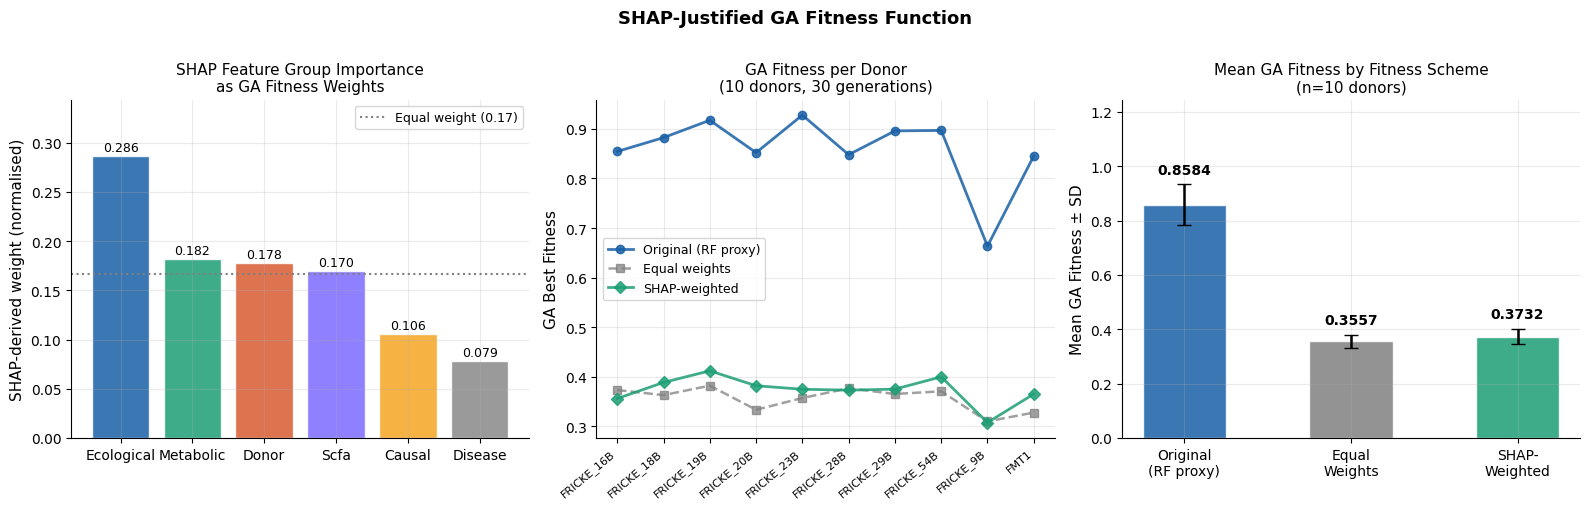

Fig_GA_fitness_comparison.png saved


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
groups_sorted = sorted(GA_SHAP_WEIGHTS.items(), key=lambda x: -x[1])
group_names   = [g.capitalize() for g, _ in groups_sorted]
group_vals    = [v for _, v in groups_sorted]

_palette_cycle = [PALETTE['primary'], PALETTE['accent'], PALETTE['warn'],
                  PALETTE['violet'], PALETTE.get('amber', '#c99a2e'), '#888888']
colors_g = [_palette_cycle[i % len(_palette_cycle)] for i in range(len(groups_sorted))]

bars = ax.bar(group_names, group_vals, color=colors_g, alpha=0.85, edgecolor='white')
ax.axhline(1/len(GA_SHAP_WEIGHTS), color='grey', ls=':', lw=1.5,
           label=f'Equal weight ({1/len(GA_SHAP_WEIGHTS):.2f})')
for bar, val in zip(bars, group_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_ylabel('SHAP-derived weight (normalised)', fontsize=11)
ax.set_title('SHAP Feature Group Importance\nas GA Fitness Weights', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, max(group_vals) * 1.2)

ax = axes[1]
x  = np.arange(len(compare_df))
ax.plot(x, compare_df['fitness_original'], 'o-', color=PALETTE['primary'],
        lw=2, ms=6, label='Original (RF proxy)', alpha=0.85)
ax.plot(x, compare_df['fitness_equal'],    's--', color='grey',
        lw=1.8, ms=6, label='Equal weights', alpha=0.75)
ax.plot(x, compare_df['fitness_shap'],     'D-', color=PALETTE['accent'],
        lw=2, ms=6, label='SHAP-weighted', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(
    [d[:10] for d in compare_df['donor_id']], rotation=40, ha='right', fontsize=8
)
ax.set_ylabel('GA Best Fitness', fontsize=11)
ax.set_title(f'GA Fitness per Donor\n({N_DONORS_COMPARE} donors, {N_GEN} generations)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[2]
schemes = ['fitness_original', 'fitness_equal', 'fitness_shap']
labels_bar = ['Original\n(RF proxy)', 'Equal\nWeights', 'SHAP-\nWeighted']
means  = [compare_df[s].mean() for s in schemes]
stds   = [compare_df[s].std()  for s in schemes]
colors_bar = [PALETTE['primary'], 'grey', PALETTE['accent']]

bars   = ax.bar(labels_bar, means, color=colors_bar, alpha=0.85,
                edgecolor='white', width=0.5)
ax.errorbar(labels_bar, means, yerr=stds,
            fmt='none', color='black', capsize=5, linewidth=1.8)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.04,
            f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean GA Fitness ± SD', fontsize=11)
ax.set_title(f'Mean GA Fitness by Fitness Scheme\n(n={N_DONORS_COMPARE} donors)', fontsize=11)
ax.set_ylim(0, max(means) * 1.45)

plt.suptitle('SHAP-Justified GA Fitness Function', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/final/Fig_GA_fitness_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_GA_fitness_comparison.png saved')

In [16]:
from sklearn.utils import resample

N_BOOT = 1000

def bootstrap_metrics(y_true, y_prob, n_boot=N_BOOT, seed=42):
    rng  = np.random.RandomState(seed)
    aucs, auprs = [], []
    y_true_arr = np.array(y_true)
    for _ in range(n_boot):
        idx = rng.choice(len(y_true_arr), size=len(y_true_arr), replace=True)
        yt  = y_true_arr[idx]
        yp  = y_prob[idx]
        if len(np.unique(yt)) < 2: continue
        aucs.append(roc_auc_score(yt, yp))
        auprs.append(average_precision_score(yt, yp))
    auc_ci  = np.percentile(aucs,  [2.5, 97.5])
    aupr_ci = np.percentile(auprs, [2.5, 97.5])
    return auc_ci, aupr_ci, np.mean(aucs), np.mean(auprs)

print(f'Running {N_BOOT} bootstrap iterations...')
auc_ci, aupr_ci, auc_mean, aupr_mean = bootstrap_metrics(
    y_test_base, y_prob_base
)

print(f'\n── Bootstrap Results (n={N_BOOT} iterations) ──')
print(f'AUROC:  {auc_mean:.4f}  (95% CI: {auc_ci[0]:.4f} – {auc_ci[1]:.4f})')
print(f'AUPRC:  {aupr_mean:.4f}  (95% CI: {aupr_ci[0]:.4f} – {aupr_ci[1]:.4f})')

print(f'Random Forest  AUROC = {auc_mean:.3f} (95% CI: {auc_ci[0]:.3f}–{auc_ci[1]:.3f})')
print(f'Random Forest  AUPRC = {aupr_mean:.3f} (95% CI: {aupr_ci[0]:.3f}–{aupr_ci[1]:.3f})')

ci_table = pd.DataFrame([{
    'Model':       'Random Forest',
    'AUROC':       round(auc_mean, 4),
    'AUROC_CI_lo': round(auc_ci[0], 4),
    'AUROC_CI_hi': round(auc_ci[1], 4),
    'AUPRC':       round(aupr_mean, 4),
    'AUPRC_CI_lo': round(aupr_ci[0], 4),
    'AUPRC_CI_hi': round(aupr_ci[1], 4),
    'N_bootstrap': N_BOOT,
}])
ci_table.to_csv('../results/Table_bootstrap_CI.csv', index=False)
print('\nTable_bootstrap_CI.csv saved')

Running 1000 bootstrap iterations...

── Bootstrap Results (n=1000 iterations) ──
AUROC:  0.7777  (95% CI: 0.7587 – 0.7967)
AUPRC:  0.7922  (95% CI: 0.7693 – 0.8142)
Random Forest  AUROC = 0.778 (95% CI: 0.759–0.797)
Random Forest  AUPRC = 0.792 (95% CI: 0.769–0.814)

Table_bootstrap_CI.csv saved
